# **Limpieza y Arreglo de la Base**

In [1]:
# lIBRERIAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [2]:
base_NNA = pd.read_excel(r"C:\Users\aleja\OneDrive\Escritorio\Python - Data Mining\Base\base_datos_completa_NNA_TI_anon.xlsx", sheet_name = "BD")
print("Cargue de los datos")
print("Filas y columnas:", base_NNA.shape)

Cargue de los datos
Filas y columnas: (56473, 115)


In [3]:
base_NNA.head(5)

,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO_INTERVENCION,PERFIL,TIPO INTERVENCIÓN,...,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,"Sub-Sección => Intervención de Niño, Niña o Adolescente",Sub-Sección => RESULTADOS DE LA INTERVENCIÓN,ADOLESCENTE TRABAJO PROTEGIDO,Sub-Sección => RESULTADOS DE LA REPOSICION,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21 00:00:00,No,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21 00:00:00,Si,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21 00:00:00,Si,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-26 00:00:00,Si,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,99999,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21 00:00:00,No,99999,99999,99999,99999,2023-10-13 00:00:00,99999,99999


In [4]:
ResumenTipos = base_NNA.dtypes
ResumenTipos.value_counts()

object            90
int64             21
float64            3
datetime64[ns]     1
Name: count, dtype: int64

## **Primera Fase: Comportamiento de los datos Faltantes**

In [5]:
base_NNA = base_NNA.replace(99999, np.nan)
base_NNA = base_NNA.replace(["N/A", "NA", "n/a", "NaN", "nan"], np.nan)
base_NNA.head(5) # Se valida el cambio 

C:\Users\aleja\AppData\Local\Temp\ipykernel_10508\3443289932.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_NNA = base_NNA.replace(99999, np.nan)


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO_INTERVENCION,PERFIL,TIPO INTERVENCIÓN,...,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,"Sub-Sección => Intervención de Niño, Niña o Adolescente",Sub-Sección => RESULTADOS DE LA INTERVENCIÓN,ADOLESCENTE TRABAJO PROTEGIDO,Sub-Sección => RESULTADOS DE LA REPOSICION,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,NaN,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21,No,NaN,NaN,NaN,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,NaN,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21,Si,NaN,NaN,NaN,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,NaN,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21,Si,NaN,NaN,NaN,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,NaN,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-26,Si,NaN,NaN,NaN,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,NaN,Tecnólogo en Salud Ocupacional,2. Niños - Niñas,...,Si,2025-02-21,No,NaN,NaN,NaN,NaN,2023-10-13,NaN,NaN


In [6]:
tipo_variables = pd.DataFrame({
    'Variable': base_NNA .columns,
    'Tipo_de_dato': base_NNA .dtypes.values,
    'Valores_nulos_%': base_NNA .isnull().mean().round(4).mul(100).values
})

pd.set_option('display.max_rows', None) # limitar si es muy largo
tipo_variables.head(115)

,Variable,Tipo_de_dato,Valores_nulos_%
0,Id_fic,int64,0.00
1,Base_Origen,object,0.00
2,Ficha_fic,int64,0.00
3,Fecha_intervencion,datetime64[ns],0.00
4,Localidad_fic,object,0.00
5,Red_fic,object,0.00
6,Usuario,object,0.00
7,TIPO_INTERVENCION,object,85.70
8,PERFIL,object,91.75
9,TIPO INTERVENCIÓN,object,14.33


C:\Users\aleja\AppData\Local\Temp\ipykernel_10508\1096606734.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


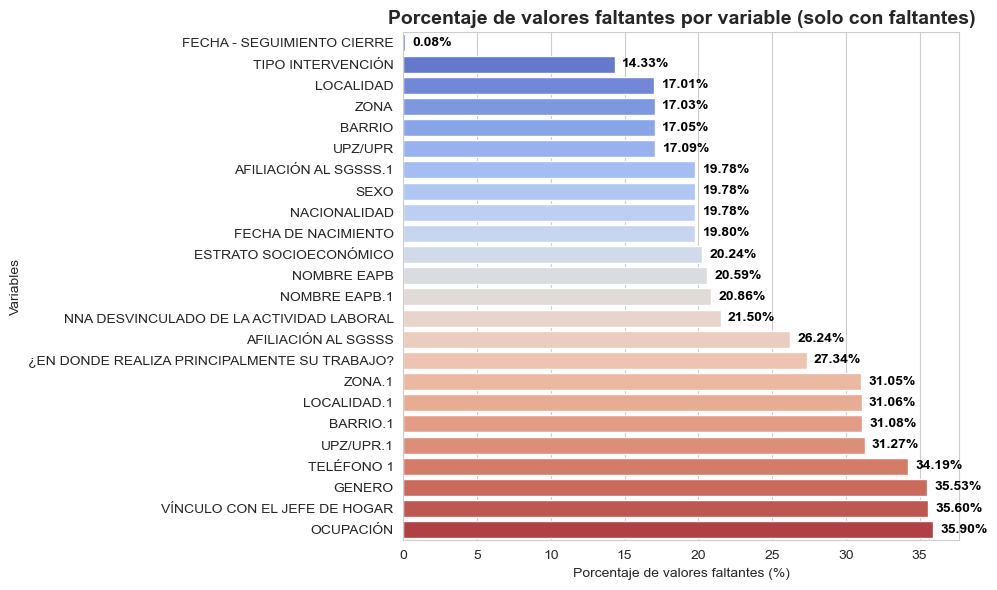

In [7]:
ruta_img = r"C:\Users\aleja\OneDrive\Escritorio\Python - Data Mining\Limpieza de los Datos\Imagenes"
# Grupos de valores faltantes para tratar
faltantes = tipo_variables[
    (tipo_variables['Valores_nulos_%'] > 0) & 
    (tipo_variables['Valores_nulos_%'] <= 40)].copy()

# Ordenar por porcentaje de nulos (de menor a mayor)
faltantes = faltantes.sort_values('Valores_nulos_%', ascending=True)

# gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=faltantes,
    x='Valores_nulos_%',
    y='Variable',
    palette='coolwarm'
)

# Agregar etiquetas con el porcentaje al final de cada barra
for i, (valor, variable) in enumerate(zip(faltantes['Valores_nulos_%'], faltantes['Variable'])):
    plt.text(valor + 0.5, i, f'{valor:.2f}%', color='black', va='center', fontweight='bold')

# Títulos y etiquetas
plt.title('Porcentaje de valores faltantes por variable (solo con faltantes)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.ylabel('Variables')

# Guardar la figura completa como PNG
ruta_guardado = os.path.join(ruta_img, "Limpieza_Grafica1.png")
plt.savefig(ruta_guardado, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()




C:\Users\aleja\AppData\Local\Temp\ipykernel_10508\2911037827.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


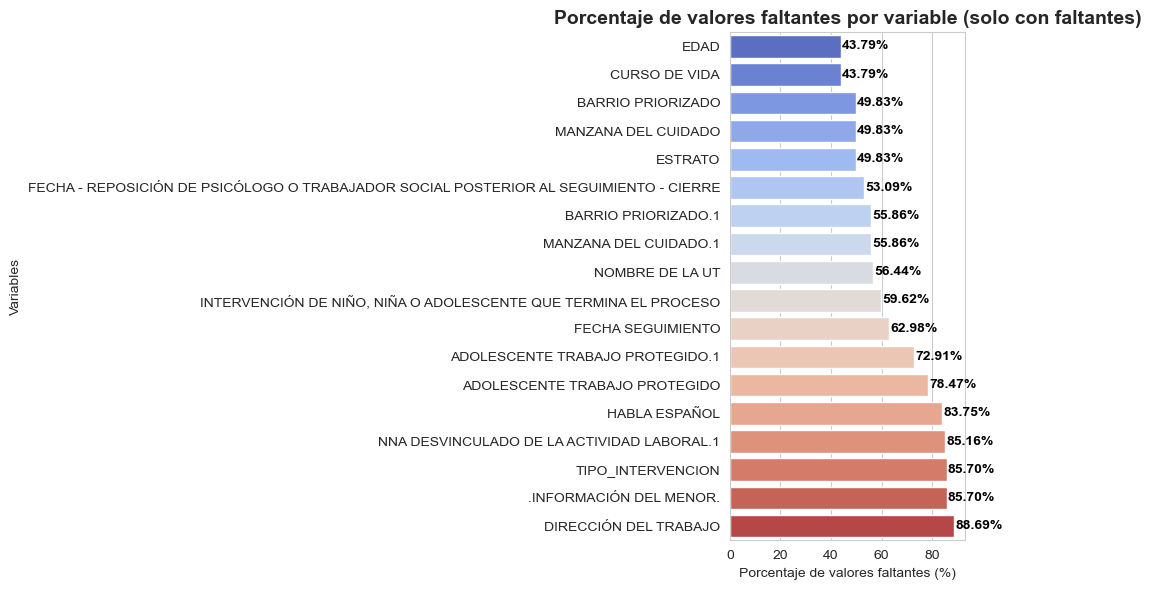

In [8]:
# Grupos de valores faltantes para tratar
faltantes = tipo_variables[
    (tipo_variables['Valores_nulos_%'] > 40) & 
    (tipo_variables['Valores_nulos_%'] <= 90)].copy()

# Ordenar por porcentaje de nulos (de menor a mayor)
faltantes = faltantes.sort_values('Valores_nulos_%', ascending=True)

# gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=faltantes,
    x='Valores_nulos_%',
    y='Variable',
    palette='coolwarm'
)

# Agregar etiquetas con el porcentaje al final de cada barra
for i, (valor, variable) in enumerate(zip(faltantes['Valores_nulos_%'], faltantes['Variable'])):
    plt.text(valor + 0.5, i, f'{valor:.2f}%', color='black', va='center', fontweight='bold')

# Títulos y etiquetas
plt.title('Porcentaje de valores faltantes por variable (solo con faltantes)', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.ylabel('Variables')

# Guardar la figura completa como PNG
ruta_guardado = os.path.join(ruta_img, "Limpieza_Grafica2.png")
plt.savefig(ruta_guardado, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [9]:
# Grupos de valores faltantes para tratar
faltantes = tipo_variables[
    (tipo_variables['Valores_nulos_%'] > 90) ]

# Ordenar de mayor a menor porcentaje de nulos
faltantes = faltantes.sort_values('Valores_nulos_%', ascending=False)

# Definir ruta base
ruta_base = r"C:\Users\aleja\OneDrive\Escritorio\Python - Data Mining\Limpieza de los Datos\Tablas"
faltantes.to_excel(os.path.join(ruta_base, "Tabla_Faltantes_Mayores_90%.xlsx"), index=False)

pd.set_option('display.max_rows', None)
faltantes


,Variable,Tipo_de_dato,Valores_nulos_%
111,Sub-Sección => RESULTADOS DE LA REPOSICION,float64,100.00
108,"Sub-Sección => Intervención de Niño, Niña o Ad...",float64,100.00
50,Sub-Sección => INFORMACIÓN DEL ACUDIENTE,float64,100.00
79,ACOMPAÑAMIENTO 3,float64,100.00
86,ACOMPAÑAMIENTO 4,float64,100.00
47,ÚLTIMA INTERVENCIÓN,float64,100.00
72,ACOMPAÑAMIENTO 2,float64,100.00
11,Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENT...,float64,100.00
54,Sub-Sección => INFORMACIÓN LABORAL,float64,100.00
31,DIRECCIÓN DE LA VIVIENDA,float64,100.00


## **Segunda Fase: Limpieza y Eliminacion**

In [10]:
# Obtener los nombres reales de las variables a eliminar
vars_a_eliminar = faltantes['Variable'].tolist()

# Crear la base limpia excluyendo esas variables
Data_Limpia = base_NNA.drop(columns=vars_a_eliminar, errors='ignore')


print("Tamaño original:", base_NNA.shape)
print("Tamaño después de limpieza:", Data_Limpia.shape)
print("\nVariables eliminadas por alto porcentaje de nulos (>90%):")
print(vars_a_eliminar)




Tamaño original: (56473, 115)
Tamaño después de limpieza: (56473, 53)

Variables eliminadas por alto porcentaje de nulos (>90%):
['Sub-Sección => RESULTADOS DE LA REPOSICION', 'Sub-Sección => Intervención de Niño, Niña o Adolescente', 'Sub-Sección => INFORMACIÓN DEL ACUDIENTE', 'ACOMPAÑAMIENTO 3', 'ACOMPAÑAMIENTO 4', 'ÚLTIMA INTERVENCIÓN', 'ACOMPAÑAMIENTO 2', 'Sub-Sección => INFORMACIÓN DEL MENOR NNA IDENTIFICADO COMO TRABAJADOR', 'Sub-Sección => INFORMACIÓN LABORAL', 'DIRECCIÓN DE LA VIVIENDA', 'Sub-Sección => RESULTADOS DE LA INTERVENCIÓN', 'VEREDA', 'CORREO  2', 'RazonAbandonoEscolar', 'ESPECIAL', 'ESPECIAL.1', 'SUBGRUPO SISBEN', 'PUEBLO', 'IdNivelEducativo', 'NÚMERO DE FICHA ANTERIOR', 'FECHA DE LA ÚLTIMA INTERVENCIÓN', 'ETAPA DE GESTACIÓN', 'CUMPLIÓ.3', 'CUMPLIÓ.2', 'ALERTAS EN MUJERES', 'ALERTAS EN NUTRICIÓN', 'CUMPLIÓ.1', 'CUMPLIÓ', 'ALERTAS PSICOSOCIALES.2', 'FECHA.1', 'IEC.2', 'TEMAS TRATADOS.1', 'PERFIL.2', 'ALERTAS PSICOSOCIALES.1', 'FECHA', 'TEMAS TRATADOS', 'PERFIL.1', 'IE

In [11]:
# Variables a analizar
variables_categoricas = ['TIPO_INTERVENCION', 'TIPO INTERVENCIÓN']

for var in variables_categoricas:
    if var in Data_Limpia.columns:
        print(f"SUMMARY VARIABLE: {var}")
        print(Data_Limpia[var].describe(include='all'))
        
        # Frecuencias absolutas y relativas
        freq = Data_Limpia[var].value_counts(dropna=False)
        perc = Data_Limpia[var].value_counts(normalize=True, dropna=False) * 100

        resumen = pd.DataFrame({
            'Frecuencia': freq,
            'Porcentaje (%)': perc.round(2)
        })

        print("\n Frecuencias y porcentajes de las categorías más comunes:")
        print(resumen.head(10))
        print("\n")
    else:
        print(f"⚠️ La variable '{var}' no se encuentra en la base de datos.\n")


SUMMARY VARIABLE: TIPO_INTERVENCION
count            8075
unique              3
top       Niños-Niñas
freq             4669
Name: TIPO_INTERVENCION, dtype: object

 Frecuencias y porcentajes de las categorías más comunes:
                       Frecuencia  Porcentaje (%)
TIPO_INTERVENCION                                
NaN                         48398           85.70
Niños-Niñas                  4669            8.27
Seguimiento al efecto        2441            4.32
Adolescentes                  965            1.71


SUMMARY VARIABLE: TIPO INTERVENCIÓN
count                48383
unique                   5
top       2. Niños - Niñas
freq                 32275
Name: TIPO INTERVENCIÓN, dtype: object

 Frecuencias y porcentajes de las categorías más comunes:
                                       Frecuencia  Porcentaje (%)
TIPO INTERVENCIÓN                                                
2. Niños - Niñas                            32275           57.15
5. Seguimiento al efecto            

In [12]:
mapeo_intervencion = {
    'Niños-Niñas': '2. Niños - Niñas',
    'Seguimiento al efecto': '5. Seguimiento al efecto',
    'Adolescentes': '3. Adolescentes'
}

# Reemplazar valores en la variable
Data_Limpia['TIPO_INTERVENCION'] = Data_Limpia['TIPO_INTERVENCION'].replace(mapeo_intervencion)
print(Data_Limpia['TIPO_INTERVENCION'].value_counts(dropna=False))


TIPO_INTERVENCION
NaN                         48398
2. Niños - Niñas             4669
5. Seguimiento al efecto     2441
3. Adolescentes               965
Name: count, dtype: int64


In [13]:
# Reemplazar valores faltantes de "TIPO INTERVENCIÓN" con los de TIPO_INTERVENCION
Data_Limpia['TIPO INTERVENCIÓN'] = Data_Limpia['TIPO INTERVENCIÓN'].fillna(Data_Limpia['TIPO_INTERVENCION'])

# Verificar resultado
print(Data_Limpia[['TIPO_INTERVENCION', 'TIPO INTERVENCIÓN']].head(5))
Data_Limpia.head(5)

  TIPO_INTERVENCION TIPO INTERVENCIÓN
0               NaN  2. Niños - Niñas
1               NaN  2. Niños - Niñas
2               NaN  2. Niños - Niñas
3               NaN  2. Niños - Niñas
4               NaN  2. Niños - Niñas


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO_INTERVENCION,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,...,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,FECHA SEGUIMIENTO,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,ADOLESCENTE TRABAJO PROTEGIDO,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,NaN,2. Niños - Niñas,NaN,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,NaN,2. Niños - Niñas,NaN,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,NaN,2. Niños - Niñas,NaN,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,NaN,2. Niños - Niñas,NaN,...,ERIKAPULIDO NAILS,NaN,2024-12-10 00:00:00,Si,2025-02-26,Si,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,NaN,2. Niños - Niñas,NaN,...,VENTA DE DULCES,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN


In [14]:
# Eliminar la variable TIPO_INTERVENCION
Data_Limpia = Data_Limpia.drop(columns=['TIPO_INTERVENCION'], errors='ignore')
# NaN que quedaron 
num_nan = Data_Limpia['TIPO INTERVENCIÓN'].isna().sum()

print(f" Variable 'TIPO_INTERVENCION' eliminada correctamente.")
print(f" Número de valores NaN en 'TIPO INTERVENCIÓN': {num_nan}")
Data_Limpia.head(5)

 Variable 'TIPO_INTERVENCION' eliminada correctamente.
 Número de valores NaN en 'TIPO INTERVENCIÓN': 15


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,NACIONALIDAD,...,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,FECHA SEGUIMIENTO,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,ADOLESCENTE TRABAJO PROTEGIDO,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,2. Niños - Niñas,NaN,Colombia,...,ERIKAPULIDO NAILS,NaN,2024-12-10 00:00:00,Si,2025-02-26,Si,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Venezuela (Bolivarian Republic of),...,VENTA DE DULCES,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN


In [15]:
Data_Limpia['EDAD'] = Data_Limpia['EDAD'].astype('Int64')
# Calcular la edad estimada en años (diferencia entre las fechas)
Data_Limpia['EDAD_CALCULADA'] = (
    (Data_Limpia['Fecha_intervencion'] - Data_Limpia['FECHA DE NACIMIENTO'])
    .dt.days / 365
).round().astype('Int64')
Data_Limpia.loc[Data_Limpia['EDAD'] < 0, 'EDAD'] = 0
# Completar los valores faltantes de EDAD con los de EDAD_CALCULADA
Data_Limpia['EDAD'] = Data_Limpia['EDAD'].fillna(Data_Limpia['EDAD_CALCULADA'])

# Opcional: eliminar la variable auxiliar
Data_Limpia = Data_Limpia.drop(columns=['EDAD_CALCULADA'])

# Mostrar verificación
faltantes_edad = Data_Limpia['EDAD'].isna().sum()
print(f" Variable 'EDAD' completada usando fechas disponibles.")
print(f"🔹 Registros aún faltantes: {faltantes_edad}")


 Variable 'EDAD' completada usando fechas disponibles.
🔹 Registros aún faltantes: 11178


In [16]:
# Ver las categorías únicas
categorias = Data_Limpia['CURSO DE VIDA'].unique()
print(categorias)

# También puedes ver cuántas veces aparece cada categoría
frecuencias = Data_Limpia['CURSO DE VIDA'].value_counts(dropna=False)
print("\nFrecuencias por categoría:")
print(frecuencias)


[nan 'primera infancia' 'infancia' 'adolescencia' 'juventud']

Frecuencias por categoría:
CURSO DE VIDA
NaN                 24728
infancia            12947
adolescencia        10355
primera infancia     8407
juventud               36
Name: count, dtype: int64


In [17]:
# Definir una función para clasificar según la edad
def asignar_curso_vida(edad):
    if pd.isna(edad):
        return np.nan
    elif edad <= 5:
        return 'Primera infancia'
    elif edad < 12:
        return 'Infancia'
    elif edad < 18:
        return 'Adolescencia'
    else:
        return 'Juventud'

# Solo rellenar los valores faltantes en 'CURSO DE VIDA'
Data_Limpia['CURSO DE VIDA'] = Data_Limpia['CURSO DE VIDA'].fillna(
    Data_Limpia['EDAD'].apply(asignar_curso_vida)
)
print("Distribución de la variable CURSO DE VIDA después de imputar:")
print(Data_Limpia['CURSO DE VIDA'].value_counts(dropna=False))

Distribución de la variable CURSO DE VIDA después de imputar:
CURSO DE VIDA
infancia            12947
NaN                 11178
adolescencia        10355
primera infancia     8407
Infancia             5263
Adolescencia         4602
Primera infancia     3419
Juventud              266
juventud               36
Name: count, dtype: int64


In [18]:
# Variables a analizar
variables_categoricas = ['AFILIACIÓN AL SGSSS', 'AFILIACIÓN AL SGSSS.1']

for var in variables_categoricas:
    if var in Data_Limpia.columns:
        print(f"SUMMARY VARIABLE: {var}")
        print(Data_Limpia[var].describe(include='all'))
        
        # Frecuencias absolutas y relativas
        freq = Data_Limpia[var].value_counts(dropna=False)
        perc = Data_Limpia[var].value_counts(normalize=True, dropna=False) * 100

        resumen = pd.DataFrame({
            'Frecuencia': freq,
            'Porcentaje (%)': perc.round(2)
        })

        print("\n Frecuencias y porcentajes de las categorías más comunes:")
        print(resumen.head(10))
        print("\n")
    else:
        print(f"⚠️ La variable '{var}' no se encuentra en la base de datos.\n")

SUMMARY VARIABLE: AFILIACIÓN AL SGSSS
count             41656
unique                5
top       1- Subsidiado
freq              19024
Name: AFILIACIÓN AL SGSSS, dtype: object

 Frecuencias y porcentajes de las categorías más comunes:
                                  Frecuencia  Porcentaje (%)
AFILIACIÓN AL SGSSS                                         
1- Subsidiado                          19024           33.69
2- Contributivo                        15514           27.47
NaN                                    14817           26.24
5- No asegurado                         6488           11.49
3- Régimen de excepción/especial         625            1.11
4- Vinculado                               5            0.01


SUMMARY VARIABLE: AFILIACIÓN AL SGSSS.1
count             45302
unique                5
top       1- Subsidiado
freq              20194
Name: AFILIACIÓN AL SGSSS.1, dtype: object

 Frecuencias y porcentajes de las categorías más comunes:
                                  Frec

In [19]:
mapeo_afiliacion = {
    '1. Subsidiado':'1- Subsidiado',
    '2. Contributivo':'2- Contributivo',
    '3. Régimen de excepción o especial':'3- Régimen de excepción/especial',
    '4. Vinculado':'4- Vinculado',
    '5. No asegurado':'5- No asegurado'
    
}

Data_Limpia['AFILIACIÓN AL SGSSS'] = Data_Limpia['AFILIACIÓN AL SGSSS'].replace(mapeo_afiliacion)
print(Data_Limpia['AFILIACIÓN AL SGSSS'].value_counts(dropna=False))


AFILIACIÓN AL SGSSS
1- Subsidiado                       19024
2- Contributivo                     15514
NaN                                 14817
5- No asegurado                      6488
3- Régimen de excepción/especial      625
4- Vinculado                            5
Name: count, dtype: int64


In [20]:
Data_Limpia['AFILIACIÓN AL SGSSS.1'] = Data_Limpia['AFILIACIÓN AL SGSSS.1'].fillna(Data_Limpia['AFILIACIÓN AL SGSSS'])

# Verificar resultado
print(Data_Limpia[['AFILIACIÓN AL SGSSS', 'AFILIACIÓN AL SGSSS.1']].head(5))
Data_Limpia.head(5)

  AFILIACIÓN AL SGSSS AFILIACIÓN AL SGSSS.1
0       1- Subsidiado       5- No asegurado
1       1- Subsidiado         1- Subsidiado
2       1- Subsidiado         1- Subsidiado
3       1- Subsidiado         1- Subsidiado
4     5- No asegurado       5- No asegurado


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,NACIONALIDAD,...,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,FECHA SEGUIMIENTO,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,ADOLESCENTE TRABAJO PROTEGIDO,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,2. Niños - Niñas,NaN,Colombia,...,ERIKAPULIDO NAILS,NaN,2024-12-10 00:00:00,Si,2025-02-26,Si,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Venezuela (Bolivarian Republic of),...,VENTA DE DULCES,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN


In [21]:
# Eliminar la variable TIPO_INTERVENCION
Data_Limpia = Data_Limpia.drop(columns=['AFILIACIÓN AL SGSSS'], errors='ignore')
# NaN que quedaron 
num_nan = Data_Limpia['AFILIACIÓN AL SGSSS.1'].isna().sum()

print(f" Variable 'AFILIACIÓN AL SGSSS' eliminada correctamente.")
print(f" Número de valores NaN en 'AFILIACIÓN AL SGSSS.1': {num_nan}")
Data_Limpia.head(5)

 Variable 'AFILIACIÓN AL SGSSS' eliminada correctamente.
 Número de valores NaN en 'AFILIACIÓN AL SGSSS.1': 11171


,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO INTERVENCIÓN,.INFORMACIÓN DEL MENOR.,NACIONALIDAD,...,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,FECHA SEGUIMIENTO,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,ADOLESCENTE TRABAJO PROTEGIDO,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,2. Niños - Niñas,NaN,Colombia,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,2. Niños - Niñas,NaN,Colombia,...,ERIKAPULIDO NAILS,NaN,2024-12-10 00:00:00,Si,2025-02-26,Si,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,NaN,Venezuela (Bolivarian Republic of),...,VENTA DE DULCES,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN


In [22]:
tipo_variables1 = pd.DataFrame({
    'Variable': Data_Limpia.columns,  # mostrar solo los primeros 18 caracteres
    'Tipo_de_dato': Data_Limpia.dtypes.values,
    'Valores_nulos_%': Data_Limpia.isnull().mean().round(4).mul(100).values
})

pd.set_option('display.max_rows', None) # limitar si es muy largo
tipo_variables1.head(51)


,Variable,Tipo_de_dato,Valores_nulos_%
0,Id_fic,int64,0.00
1,Base_Origen,object,0.00
2,Ficha_fic,int64,0.00
3,Fecha_intervencion,datetime64[ns],0.00
4,Localidad_fic,object,0.00
5,Red_fic,object,0.00
6,Usuario,object,0.00
7,TIPO INTERVENCIÓN,object,0.03
8,.INFORMACIÓN DEL MENOR.,float64,85.70
9,NACIONALIDAD,object,19.78


In [30]:
# Eliminar las columnas que no se considera que aporten
columnas_a_eliminar = ['.INFORMACIÓN DEL MENOR.', 'HABLA ESPAÑOL', 'TELÉFONO 1', 'DIRECCIÓN DEL TRABAJO']
Data_Limpia = Data_Limpia.drop(columns=columnas_a_eliminar, errors='ignore')


Data_Limpia.head(5)

,Id_fic,Base_Origen,Ficha_fic,Fecha_intervencion,Localidad_fic,Red_fic,Usuario,TIPO INTERVENCIÓN,NACIONALIDAD,SEXO,...,NOMBRE DE LA UT,¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?,FECHA SEGUIMIENTO,"INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO",FECHA - SEGUIMIENTO CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL,ADOLESCENTE TRABAJO PROTEGIDO,FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE,NNA DESVINCULADO DE LA ACTIVIDAD LABORAL.1,ADOLESCENTE TRABAJO PROTEGIDO.1
0,1977498,dic24_mar25,3190244966,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,Colombia,1- Hombre,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN
1,1977499,dic24_mar25,3190244967,2024-12-05,Ciudad Bolívar,Sur,estellez,2. Niños - Niñas,Colombia,2- Mujer,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
2,1977500,dic24_mar25,3190244968,2024-12-05,Ciudad Bolívar,Sur,fecelis,2. Niños - Niñas,Colombia,2- Mujer,...,TIENDA DE ROPA,NaN,2024-12-14 00:00:00,Si,2025-02-21,Si,NaN,2023-10-13,NaN,NaN
3,1977544,dic24_mar25,3060244894,2024-12-04,Tunjuelito,Sur,smroncancio,2. Niños - Niñas,Colombia,2- Mujer,...,ERIKAPULIDO NAILS,NaN,2024-12-10 00:00:00,Si,2025-02-26,Si,NaN,2023-10-13,NaN,NaN
4,1977549,dic24_mar25,3190244965,2024-12-05,Ciudad Bolívar,Sur,rapalencia,2. Niños - Niñas,Venezuela (Bolivarian Republic of),2- Mujer,...,VENTA DE DULCES,NaN,2024-12-14 00:00:00,Si,2025-02-21,No,NaN,2023-10-13,NaN,NaN


In [31]:
mapeo_red = {
    1: 'Norte',
    2: 'Centro Oriente',
    3: 'Sur',
    4: 'Suroccidente',
    '1': 'Norte',
    '2': 'Centro Oriente',
    '3': 'Sur',
    '4': 'Suroccidente'
}

# Reemplazar los valores numéricos por los nombres correspondientes
Data_Limpia['Red_fic'] = Data_Limpia['Red_fic'].replace(mapeo_red)
print("Conteo final de categorías en 'Red_fic':")
print(Data_Limpia['Red_fic'].value_counts(dropna=False))

Conteo final de categorías en 'Red_fic':
Red_fic
Centro Oriente    14652
Sur               14093
Norte             13930
Suroccidente      13798
Name: count, dtype: int64


In [33]:
Data_Limpia.loc[Data_Limpia['EDAD'] < 0, 'EDAD'] = 0

# Ciclo para resumir cada variable
for col in Data_Limpia.columns:
    print("="*50)
    print(f" SUMMARY VARIABLE: {col}")
    print("="*50)

    # Detectar tipo de variable
    tipo = Data_Limpia[col].dtype

   # Si es numérica (float, int, o pandas Int64)
    if pd.api.types.is_numeric_dtype(Data_Limpia[col]):
        print("Tipo: Numérica")
        print(f"Conteo: {Data_Limpia[col].count()}")
        print(f"Media: {Data_Limpia[col].mean():.2f}")
        print(f"Mínimo: {Data_Limpia[col].min()}")
        print(f"Máximo: {Data_Limpia[col].max()}")
        print(f"Valores faltantes: {Data_Limpia[col].isna().sum()}")
    
    # Si es fecha
    elif np.issubdtype(tipo, np.datetime64):
        print("Tipo: Fecha")
        print(f"Conteo: {Data_Limpia[col].count()}")
        print(f"Fecha mínima: {Data_Limpia[col].min()}")
        print(f"Fecha máxima: {Data_Limpia[col].max()}")
        print(f"Valores faltantes: {Data_Limpia[col].isna().sum()}")
    
    # Si es categórica u objeto
    else:
        print("Tipo: Categórica")
        print(f"Conteo: {Data_Limpia[col].count()}")
        print(f"Valores únicos: {Data_Limpia[col].nunique()}")
        print(f"Valores faltantes: {Data_Limpia[col].isna().sum()}")
        
        # Mostrar frecuencias (máximo 10 para evitar exceso)
        print("\n Frecuencias de las categorías más comunes:")
        print(Data_Limpia[col].value_counts(dropna=False).head(10))
    
    print("\n")  # Espacio entre variables


 SUMMARY VARIABLE: Id_fic
Tipo: Numérica
Conteo: 56473
Media: 1097818.92
Mínimo: 154976
Máximo: 2061436
Valores faltantes: 0


 SUMMARY VARIABLE: Base_Origen
Tipo: Categórica
Conteo: 56473
Valores únicos: 5
Valores faltantes: 0

 Frecuencias de las categorías más comunes:
Base_Origen
MARZO2023_NOVI 2024    23672
nov21_sep08_2022       11165
marzo_octubre 2021      8900
sep09_2022_mar2023      8075
dic24_mar25             4661
Name: count, dtype: int64


 SUMMARY VARIABLE: Ficha_fic
Tipo: Numérica
Conteo: 56473
Media: 8296296388.09
Mínimo: 203027130
Máximo: 41602230448
Valores faltantes: 0


 SUMMARY VARIABLE: Fecha_intervencion
Tipo: Fecha
Conteo: 56473
Fecha mínima: 2021-03-13 00:00:00
Fecha máxima: 2025-03-31 00:00:00
Valores faltantes: 0


 SUMMARY VARIABLE: Localidad_fic
Tipo: Categórica
Conteo: 56473
Valores únicos: 20
Valores faltantes: 0

 Frecuencias de las categorías más comunes:
Localidad_fic
Ciudad Bolívar        7957
Bosa                  5774
Kennedy               5431
Sub

In [34]:
import os
ruta = r"C:\Users\aleja\OneDrive\Escritorio\Python - Data Mining\Limpieza de los Datos"
os.makedirs(ruta, exist_ok=True)
archivo_salida = os.path.join(ruta, "Data_Limpia.xlsx")

# Exportar a Excel
Data_Limpia.to_excel(archivo_salida, index=False)
print(f"✅ Archivo guardado exitosamente en:\n{archivo_salida}")

import shutil
origen = "Limpieza de los datos.ipynb"
destino = r"C:\Users\aleja\OneDrive\Escritorio\Python - Data Mining\Limpieza de los Datos\Limpieza de los datos.ipynb"

shutil.copy(origen, destino)
print(f"✅ Notebook copiado a: {destino}")


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\aleja\\OneDrive\\Escritorio\\Python - Data Mining\\Limpieza de los Datos\\Data_Limpia.xlsx'